## Final Solution: Intro to Open MM Dynamics Simulations
Name: William An Do

Date: 3/17/26

## Exercise 0: The OpenMM Tools

Goal: Understand the Components of an OpenMM Stimulation

#### Step 1

In [77]:
!pip install openmm

In [78]:
!pip install py3Dmol

In [79]:
!pip install rdkit

In [80]:
# Standard Programs for Using OpenMM
from openmm import app
import openmm as mm
from simtk import unit
import sys
from openmm.app import StateDataReporter

# Other Useful Programs
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import py3Dmol
import random
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdmolfiles
import os
import zipfile

# Model Packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#### Step 2

Before we go over the tools, let's visualize the molecule for our first OpenMM simulation.

In [81]:
# Read the PDB file content
with open('/content/xe-27.pdb', 'r') as f:
    pdb_data = f.read()

# Create a py3Dmol viewer object
view = py3Dmol.view(width=800, height=600)

# Add the PDB data to the viewer
view.addModel(pdb_data, 'pdb')

# Change the style to 'sphere' to better visualize individual atoms
view.setStyle({'sphere':{}})

# Zoom to fit the model
view.zoomTo()

# Display the viewer
view

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

As you can see, the structure is just a cube of 27 xenon atoms. This will be a basic test model for our first OpenMM stimulation.

#### Step 3

**Tool 1: The PDB Model (Topology)**

In [82]:
# First we need to use OpenMM.app to convert the PDB data for the Open MM simulation
xe_pdb = app.PDBFile("xe-27.pdb")

**Tool 2: The Force Field**

In [83]:
# Next, we'll need a force field to stimulate the various forces applied in a dynamic stimulations
# Once again, we'll use OpenMM.app to load a specfic force field for xenon (these are labeled 'xml')
xe_ff = app.ForceField('xenon.xml')

**Tool 3: The System**

In [84]:
# A system defines everything needed to compute the physics of the molecular simulation.
# It takes the model and force field and provide the initial set up for the system
xe_system = xe_ff.createSystem(xe_pdb.topology)

**Tool 4: The Integrator**

In [85]:
# The integrator is the component that updates the positions and velocities of particles
# The update occur as a set time that the user controls (I set it to 1 femtosecond)
xe_integrator = mm.VerletIntegrator(0.001*unit.picosecond)

There are 3 major types of integrators:
1. **Verlet**    (Basic, Only has Timestep)
2. **Langevin** (Includes tempature control)
3. **Brownian** (Models High Friction/Cramped Models)

For this simulation, the Verlet will suffice, but feel free to look up and use the other integrators when needed.

**Tool 5: The Platform**

In [86]:
# The platform decides which hardware and computational backend will run your simulation
xe_platform = mm.Platform.getPlatformByName('CPU')

There for 4 major platforms you should consider:
1. **Reference** (Slow, Python Only, Good for poor CPUs)
2. **CPU**    (Runs on CPU)
3. **CUDA**   (NVIDIA GPU)
4. **OpenCL** (AMD GPU)

## Exercise 1: Our First OpenMM Simulation

Goal: Set Up and Run an OpenMM Simulation of the 27 Xenon cube.

#### Step 1

In [87]:
# Incorporate all the tools in exercise 0 to set up the simulation
xe_simulation = app.Simulation(xe_pdb.topology, xe_system, xe_integrator, xe_platform)

In [88]:
# Set context and minimal energy as a starting point for a simulation
xe_simulation.context.setPositions(xe_pdb.positions)
xe_simulation.minimizeEnergy()

#### Step 2/3

In [89]:
# Reporter for energies, temperature, and density
reporter1 = app.StateDataReporter("xe_data.csv",
                                  1000,              # Make sure steps is 1000 per directions
                                  step=True,
                                  temperature=True,
                                  density=True,
                                  totalEnergy=True
                                  )

# Optional: Live Reporting of the measurements of energies, temperature, and density
reporter2 = app.StateDataReporter(sys.stdout,
                                  1000,
                                  step=True,
                                  temperature=True,
                                  density=True,
                                  totalEnergy=True
                                  )

# Add the reporter to data
xe_simulation.reporters.append(reporter1)
xe_simulation.reporters.append(reporter2)

# Lists to store snapshots of positons, velo, & forces
all_positions = []
all_velocities = []
all_forces = []

# Set number of steps and measurement as per instructions
num_steps = 1000000
report_interval = 1000   # Equates to 1 picosecond

# Repeat a 1000 step simulation until 1000000 total steps haven been reached
for i in range(0, num_steps, report_interval):
    xe_simulation.step(report_interval)

    # Get current state with positions, velos, & forces
    state = xe_simulation.context.getState(getPositions=True,
                                        getVelocities=True,
                                        getForces=True)

    # Add positions, velos, and forces to a list
    all_positions.append(state.getPositions(asNumpy=True))
    all_velocities.append(state.getVelocities(asNumpy=True))
    all_forces.append(state.getForces(asNumpy=True))

# Simulations tend to take around 1 minute

#"Step","Total Energy (kJ/mole)","Temperature (K)","Density (g/mL)"
1000,-137.30960983023905,0.1946824899522952,0.7358079006442889
2000,-137.30961543070015,0.752363336358154,0.7358079006442889
3000,-137.30959131772752,0.9890298592851181,0.7358079006442889
4000,-137.30960086830424,1.047593324627857,0.7358079006442889
5000,-137.3096086920541,0.8167392735831848,0.7358079006442889
6000,-137.3096083652783,0.5786136316521904,0.7358079006442889
7000,-137.30960211037558,0.6091697650599542,0.7358079006442889
8000,-137.3096001479656,0.6219002371562794,0.7358079006442889
9000,-137.30960591766234,0.785894088350614,0.7358079006442889
10000,-137.30959807872972,0.6132849525119958,0.7358079006442889
11000,-137.3096063577901,0.7868243062372572,0.7358079006442889
12000,-137.30960285522698,7.534709256245815,0.7358079006442889
13000,-137.30964359604604,51.55147061776951,0.7358079006442889
14000,-137.30962496673195,57.383604975293636,0.7358079006442889
15000,-137.30962009593244,42.30568938044066,0.73580790

## Exercise 2: Analyzing OpenMM Data

#### Step 1

In [90]:
# Here's a df of the generated OpenMM data for the Xenon cube
xe_df = pd.read_csv('xe_data.csv')

# I needed to rename the step column to avoid quote confusion
xe_df.rename(columns={'#"Step"': 'Step #'}, inplace=True)

xe_df.head()

,Step #,Total Energy (kJ/mole),Temperature (K),Density (g/mL)
0,1000,-137.309610,0.194682,0.735808
1,2000,-137.309615,0.752363,0.735808
2,3000,-137.309591,0.989030,0.735808
3,4000,-137.309601,1.047593,0.735808
4,5000,-137.309609,0.816739,0.735808


In [91]:
# Let's add the postions, velocites, and forces to the df
xe_df["positions"] = all_positions
xe_df["velocities"] = all_velocities
xe_df["forces"] = all_forces

xe_df

,Step #,Total Energy (kJ/mole),Temperature (K),Density (g/mL),positions,velocities,forces
0,1000,-137.309610,0.194682,0.735808,"[[0.007866260085521493 nm, 0.00786626235688461...","[[-0.003490591739846449 nm/ps, -0.003490579940...","[[1.6773643493652344 kJ/(nm mol), 1.6773099899..."
1,2000,-137.309615,0.752363,0.735808,"[[0.010736553658158546 nm, 0.01073655263376556...","[[0.006030357823986338 nm/ps, 0.00603033642095...","[[-0.6466541290283203 kJ/(nm mol), -0.64665412..."
2,3000,-137.309591,0.989030,0.735808,"[[0.010494676258889408 nm, 0.01049467293281918...","[[-0.00623918727616149 nm/ps, -0.0062391710744...","[[-0.4614174962043762 kJ/(nm mol), -0.46144533..."
3,4000,-137.309601,1.047593,0.735808,"[[0.007987203613136304 nm, 0.00798720075138925...","[[0.004096883858195274 nm/ps, 0.00409688757502...","[[1.6254762411117554 kJ/(nm mol), 1.6254835128..."
4,5000,-137.309609,0.816739,0.735808,"[[0.01246380330945344 nm, 0.012463846307572997...","[[-0.0008414516249177079 nm/ps, -0.00084133727...","[[-2.2681334018707275 kJ/(nm mol), -2.26809453..."
...,...,...,...,...,...,...,...
995,996000,-137.309586,65.233522,0.735808,"[[0.12962757289051927 nm, 1.026729579167255 nm...","[[0.009944319747628994 nm/ps, -0.0116377940875...","[[-63.252899169921875 kJ/(nm mol), 12.58913135..."
996,997000,-137.309611,64.080622,0.735808,"[[0.11731754284075122 nm, 0.9885004669543214 n...","[[0.03503040977069494 nm/ps, 0.074885735264040...","[[-16.63848114013672 kJ/(nm mol), 62.776359558..."
997,998000,-137.309615,68.607838,0.735808,"[[0.1469598648798165 nm, 1.0413178960582232 nm...","[[0.06810488573474882 nm/ps, -0.05450168417131...","[[9.764205932617188 kJ/(nm mol), -34.734798431..."
998,999000,-137.309604,66.371409,0.735808,"[[0.15866023183576797 nm, 0.9368351761847028 n...","[[-0.023673876982710507 nm/ps, 0.0897127153198...","[[26.496604919433594 kJ/(nm mol), 40.504528045..."


**E2 Questions**

**You may notice that positions, velocities, and forces are presented as lists in lists. What exactly does the data in these three columns represent?**

These measurements were taken at 1000 frames for 27 Xe atoms and each atom has three measurements corresponding to x,y, and x directions. Thus, the first layer of the list is counted from 0 to 999 for the frame index. The second layer of the list is counted from 0 to 26 for the atom index. Finally, the third layer of the list is counted from 0 to 2 for the Cartesian coordinate index.  





**Why would it be more challenging running OpenMM simulations on large proteins?**

Large proteins has lots of atoms for OpenMM to consider. Every atoms requires 3 dimensional directions and will be measured at every frame. This results in extensive amounts of computation for systems with 1000s of atoms.

In [92]:
# Calls frame 1, atom 1, and the first axis (x)
# The command calls all_positions[frame #][atom #][coordinate axes #]
all_positions[999][26][2]

1.2160464041182248 nm

#### Step 2

Temperture

Text(0, 0.5, 'Count')

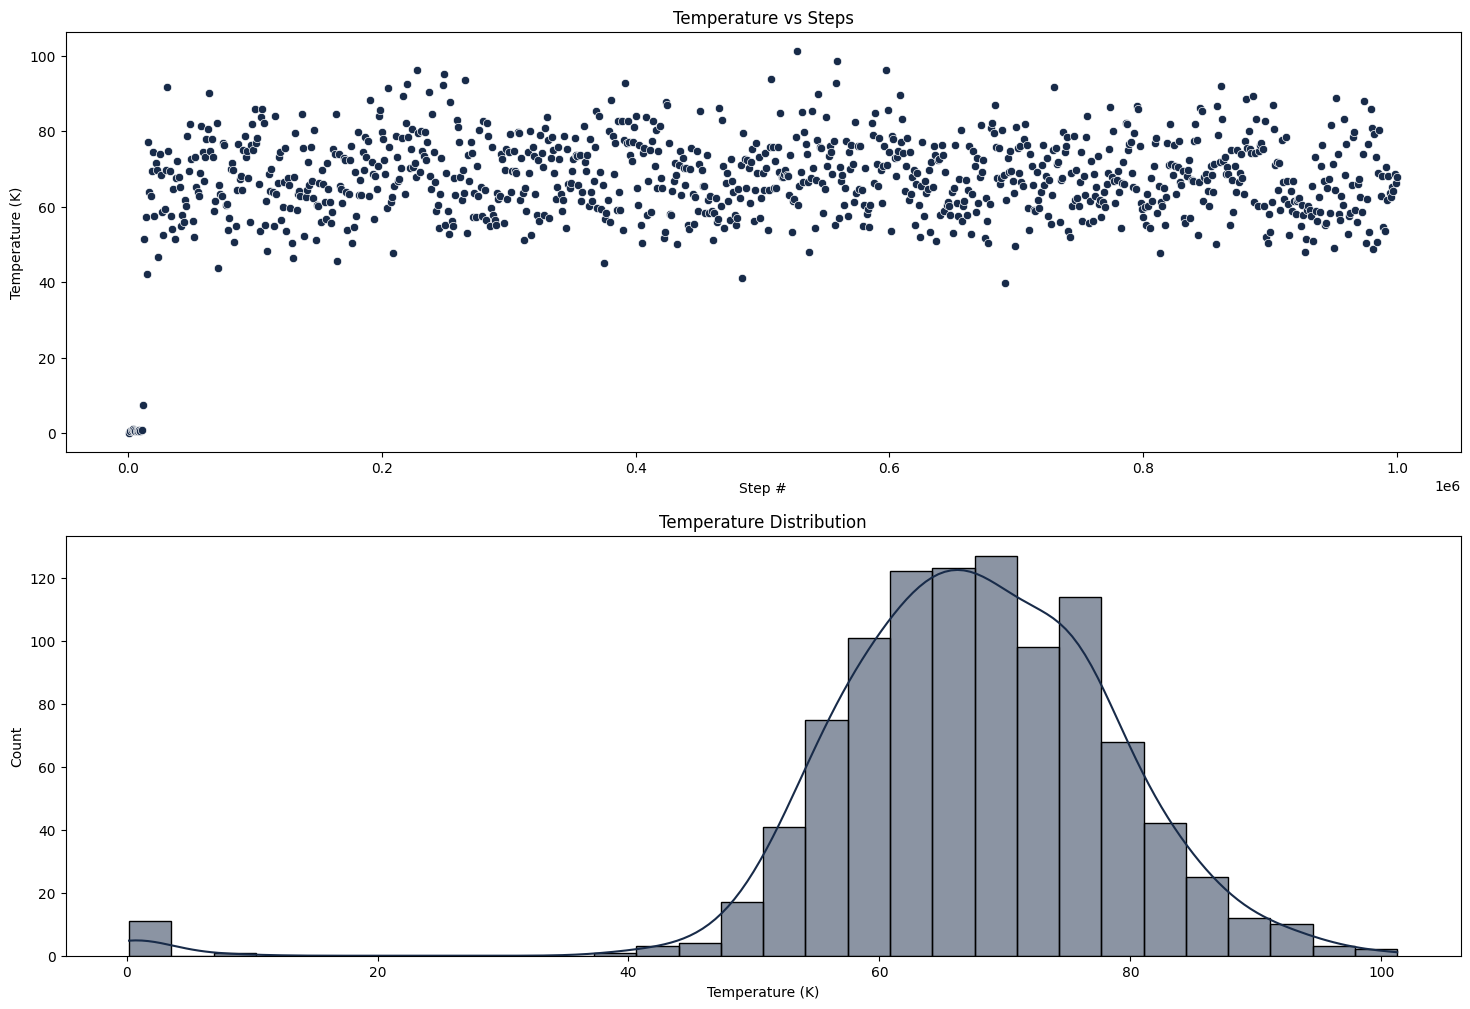

In [93]:
# Plot Outline
fig, ax = plt.subplots(2,1, figsize=(18,12))

# Temperature scatterplot code
sns.scatterplot(data=xe_df, x='Step #', y="Temperature (K)", ax=ax[0], color = '#182B49')
ax[0].set_title("Temperature vs Steps")

# Temperature histogram code
sns.histplot(data=xe_df, x="Temperature (K)", bins=30, ax=ax[1], kde=True, color = '#182B49')
ax[1].set_title("Temperature Distribution")
ax[1].set_xlabel("Temperature (K)")
ax[1].set_ylabel("Count")

Density

Text(0, 0.5, 'Count')

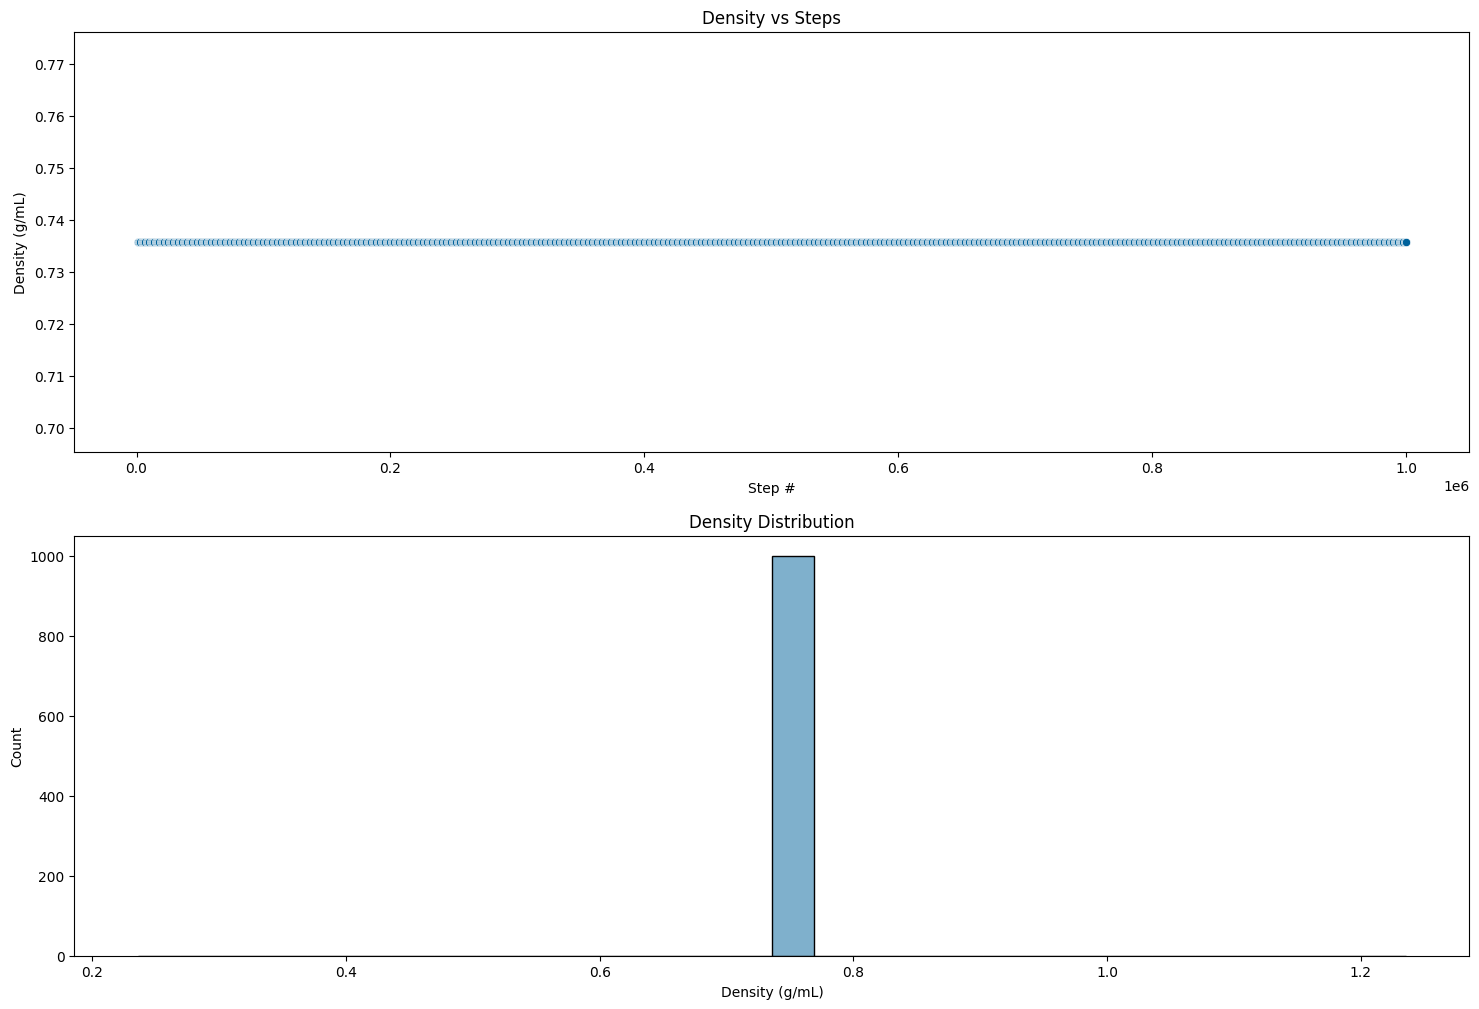

In [94]:
# Plot Outline
fig, ax = plt.subplots(2,1, figsize=(18,12))

# Density Scatter Plot Code
sns.scatterplot(data=xe_df, x="Step #", y="Density (g/mL)", ax=ax[0], color = '#00629B')
ax[0].set_title("Density vs Steps")

# Density Histogram Code
sns.histplot(data=xe_df, x="Density (g/mL)", bins=30, ax=ax[1], kde=True, color = '#00629B')
ax[1].set_title("Density Distribution")
ax[1].set_xlabel("Density (g/mL)")
ax[1].set_ylabel("Count")

Total Energy

Text(0, 0.5, 'Count')

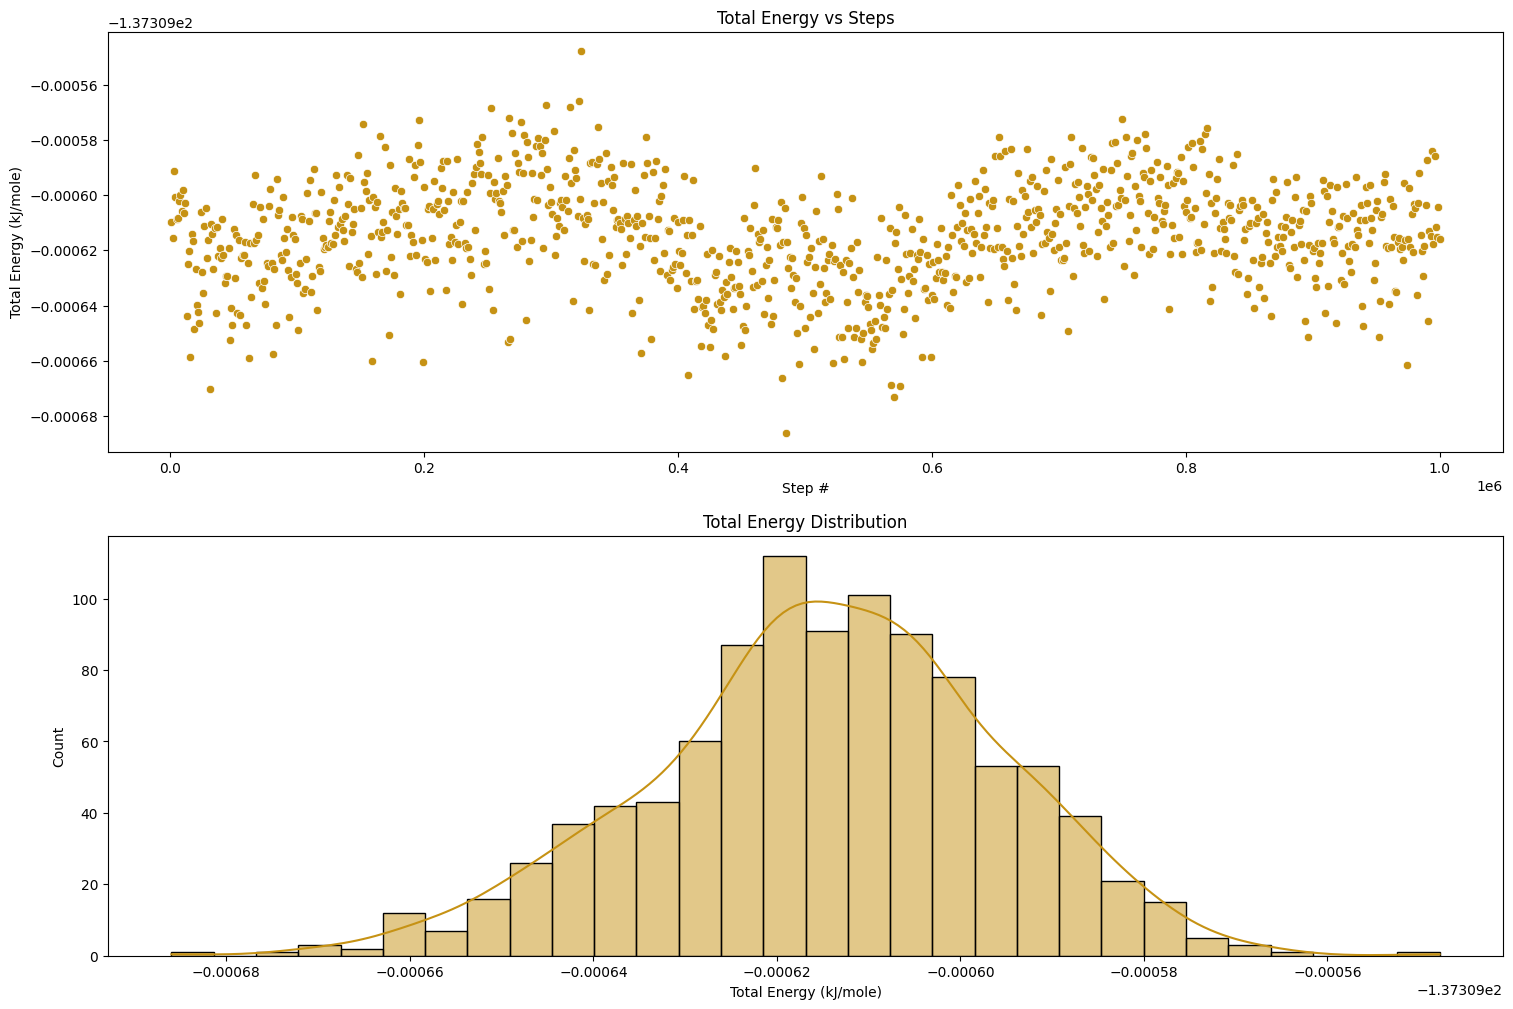

In [95]:
fig, ax = plt.subplots(2, 1, figsize=(18, 12))

# Total Energy Scatteplot Code
sns.scatterplot(data=xe_df, x="Step #", y="Total Energy (kJ/mole)", ax=ax[0], color = '#C69214')
ax[0].set_title("Total Energy vs Steps")

# Total Energy Histogram Code
sns.histplot(data=xe_df, x="Total Energy (kJ/mole)", bins=30, ax=ax[1], kde=True, color = '#C69214')
ax[1].set_title("Total Energy Distribution")
ax[1].set_xlabel("Total Energy (kJ/mole)")
ax[1].set_ylabel("Count")

In [96]:
# Mean Values for Each Variable

density = xe_df["Density (g/mL)"].mean()
temperature = xe_df["Temperature (K)"].mean()
total_energy = xe_df["Total Energy (kJ/mole)"].mean()

print(f' The average for Density is {density}')
print(f' The average for Temperature is {temperature}')
print(f' The average for Total Energy is {total_energy}')

 The average for Density is 0.7358079006442891
 The average for Temperature is 67.30274639834676
 The average for Total Energy is -137.3096148495741


**E2 Questions**

**How do each of the variables fluctuate throughout the simulation?**

The histrogram and scatterplots of the total energy is misleading since the axis intervals are very small. Thus, both density and total energy fluctuate very little throughout the simulation while temperature fluctuates a lot.


**Which plot do you prefer to showcase the variable fluctuations in a simulation?**

I believe both the scatterplot and the histrogram conveys that idea of the flucation of data through a simulation in different ways. However, I the scatterplot does a better job in showing the spread of the data compared to the histrogram. However, I will continue to do both in the future.



### Step 3

In [97]:
# Using the Ideal Gas PV = nRT, we can manipulate it into P = (mass/mol mass)RT/V or P = Density*RT/mol mass

xe27_mol_mass = 131.29 * 27   #131.29 g/mol for 27 atoms

R = 0.08206   # L*atm/mol*K

density_new = density*1000 # mL to L

pressure = (density*1000) * R * (temperature) / xe27_mol_mass

print(f'{pressure} atm')

1.1463924931291554 atm


## Exercise 3: Peptide OpenMM

#### Step 1

In [98]:
# Load AMBER force field
forcefield = app.ForceField('amber14-all.xml', 'tip3p.xml')

# Integrator parameters
temperature = 298.15*unit.kelvin
friction = 1/unit.picosecond
timestep = 1*unit.femtosecond

# Load CPU platform
platform = mm.Platform.getPlatformByName('CPU')

In [99]:
# Path to your ZIP
zip_path = "/content/PDB_Six_Peptides.zip"

# Where to extract
extract_dir = "/content/pdb6peptides"
os.makedirs(extract_dir, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [100]:
# Folder containing extracted PDBs
pdb_dir = "/content/pdb6peptides/PDB_Six_Peptides"
pdb_files = [f for f in os.listdir(pdb_dir) if f.endswith(".pdb") or f.endswith(".ent")]
print(f"Found {len(pdb_files)} PDB files.")


# Dictionary to store successful simulations
simulations = {}

# Loop over all PDBs
for pdb_name in pdb_files:
    pdb_path = os.path.join(pdb_dir, pdb_name)
    print(f"\nProcessing {pdb_name}...")

    try:
        # Load PDB
        pdb = app.PDBFile(pdb_path)

        # Add missing hydrogens
        modeller = app.Modeller(pdb.topology, pdb.positions)
        modeller.addHydrogens(forcefield)

        # Create a new integrator for this simulation
        integrator = mm.LangevinIntegrator(temperature, friction, timestep)

        # Create system
        system = forcefield.createSystem(
            modeller.topology,
        )

        # Create simulation
        sim = app.Simulation(modeller.topology, system, integrator, platform)
        sim.context.setPositions(modeller.positions)

        # Store simulation
        key = os.path.splitext(pdb_name)[0]
        simulations[key] = sim

        print(f"✅ Successfully set up {pdb_name}")

    except Exception as e:
        print(f"❌ Skipping {pdb_name} due to error: {e}")

print(f"\nFinished. {len(simulations)} simulations created successfully.")

Found 43 PDB files.

Processing pdb5zmz.ent...
✅ Successfully set up pdb5zmz.ent

Processing pdb6anm.ent...
❌ Skipping pdb6anm.ent due to error: No template found for residue 0 (DLE).  The set of atoms matches NILE, but the residue is missing 2 H-N bonds.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template

Processing pdb6dny.ent...
❌ Skipping pdb6dny.ent due to error: No template found for residue 0 (PRO).  The atoms and bonds in the residue match NPRO, but the set of externally bonded atoms has 1 N atom too many.  Is the chain terminated in a way that is unsupported by the force field?  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template

Processing pdb2olx.ent...
✅ Successfully set up pdb2olx.ent

Processing pdb4qxx.ent...
✅ Successfully set up pdb4qxx.ent

Processing pdb6qys.ent...
❌ Skipping pdb6qys.ent due to error: No template found for residue 0 (DBB).  The set of atoms is similar t

#### Step 2

In [101]:
# Folder to save outputs
output_dir = "/content/pdb6peptides/md_data"
os.makedirs(output_dir, exist_ok=True)

# MD parameters
num_steps = 50000
report_interval = 1000  # measure every 1000 steps

# Take only the first 5 entries from simulations
limited_sims = dict(list(simulations.items())[:5])

# Loop over these 5 simulations
for key, sim in limited_sims.items():
    print(f"\nRunning simulation for {key}...")

    # CSV reporter for energies, temperature, density
    reporter_csv = StateDataReporter(os.path.join(output_dir, f"{key}_data.csv"),
                                     report_interval,
                                     step=True,
                                     temperature=True,
                                     density=True,
                                     totalEnergy=True)

    # Optional live reporting
    reporter_stdout = StateDataReporter(sys.stdout,
                                        report_interval,
                                        step=True,
                                        temperature=True,
                                        density=True,
                                        totalEnergy=True)

    sim.reporters.append(reporter_csv)
    sim.reporters.append(reporter_stdout)

    # Lists to store snapshots
    all_positions = []
    all_velocities = []
    all_forces = []

    # Run the simulation in chunks of report_interval
    for i in range(0, num_steps, report_interval):
        sim.step(report_interval)

        # Get positions, velocities, forces
        state = sim.context.getState(getPositions=True,
                                     getVelocities=True,
                                     getForces=True,
                                     getEnergy=True)
        all_positions.append(state.getPositions(asNumpy=True))
        all_velocities.append(state.getVelocities(asNumpy=True))
        all_forces.append(state.getForces(asNumpy=True))

    # Save snapshots as compressed npz file
    np.savez_compressed(os.path.join(output_dir, f"{key}_snapshots.npz"),
                        positions=all_positions,
                        velocities=all_velocities,
                        forces=all_forces)

    print(f"✅ Finished simulation for {key}, data saved.")


Running simulation for pdb5zmz...
#"Step","Total Energy (kJ/mole)","Temperature (K)","Density (g/mL)"
1000,-124.05694460143727,283.5985304087295,0.2919021236719826
2000,-193.49882158516502,300.7750169623072,0.2919021236719826
3000,-259.78760693611514,299.5594531349589,0.2919021236719826
4000,-246.54742740574372,285.9177536480459,0.2919021236719826
5000,-248.44001794660963,288.72807574229154,0.2919021236719826
6000,-270.9504757298678,299.7630755135155,0.2919021236719826
7000,-235.56511613849716,348.99199056286693,0.2919021236719826
8000,-257.74042474196597,321.98052611885095,0.2919021236719826
9000,-292.7129755866018,297.44007120581415,0.2919021236719826
10000,-250.38772721758681,323.78188054670755,0.2919021236719826
11000,-234.69602659203656,296.06647289765124,0.2919021236719826
12000,-237.39576906601116,299.2209531796403,0.2919021236719826
13000,-216.7312365996729,328.2810032832705,0.2919021236719826
14000,-266.41684645958804,347.80136153472273,0.2919021236719826
15000,-309.899431662

## Exercise 4

In [102]:
# Load OpenMM Data
md_dir = "/content/pdb6peptides/md_data"
md_files = [f for f in os.listdir(md_dir) if f.endswith("_snapshots.npz")]
md_files.sort()

In [103]:
# Padding
max_atoms = 0
for md_file in md_files:
    data = np.load(os.path.join(md_dir, md_file), allow_pickle=True)
    for pos in data['positions']:
        max_atoms = max(max_atoms, pos.shape[0])
print("Max atoms across all peptides:", max_atoms)

def pad_snapshot(array, max_atoms):
    padded = np.zeros((max_atoms, 3))
    padded[:array.shape[0], :] = array
    return padded.flatten()

Max atoms across all peptides: 126


In [104]:
# Build All of the Features
entry_features = []
entry_names = []

for md_file in md_files:
    name = md_file.replace("_snapshots.npz","")
    entry_names.append(name)

    md_path = os.path.join(md_dir, md_file)
    data = np.load(md_path, allow_pickle=True)
    positions = data['positions']
    velocities = data['velocities']
    forces = data['forces']

    # Load energies
    csv_file = md_file.replace("_snapshots.npz", "_data.csv")
    df = pd.read_csv(os.path.join(md_dir, csv_file))
    energies = df['Total Energy (kJ/mole)'].values

    # Flatten + pad snapshots
    pos_padded = np.array([pad_snapshot(p, max_atoms) for p in positions])
    vel_padded = np.array([pad_snapshot(v, max_atoms) for v in velocities])
    force_padded = np.array([pad_snapshot(f, max_atoms) for f in forces])

    # Compute mean & std per peptide
    mean_pos = pos_padded.mean(axis=0)
    std_pos = pos_padded.std(axis=0)
    mean_vel = vel_padded.mean(axis=0)
    std_vel = vel_padded.std(axis=0)
    mean_force = force_padded.mean(axis=0)
    std_force = force_padded.std(axis=0)

    mean_energy = np.mean(energies)
    std_energy = np.std(energies)

    # Structural descriptors
    num_atoms = positions[0].shape[0]
    num_bonds = int(num_atoms * 1.5)   # approximate
    mol_weight = num_atoms * 110       # rough average amino acid weight

    # Combine features
    features = np.concatenate([
        mean_pos, std_pos,
        mean_vel, std_vel,
        mean_force, std_force,
        [mean_energy, std_energy],
        [num_atoms, mol_weight, num_bonds]
    ])

    entry_features.append(features)

X_entry = np.array(entry_features)
print("Entry-level feature matrix shape:", X_entry.shape)

Entry-level feature matrix shape: (19, 2273)


In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_entry)

In [106]:
from sklearn.cluster import KMeans

n_clusters = min(len(entry_names), 5)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Assign clusters to train/test to approximate 80/20
cluster_counts = {}
for l in labels:
    cluster_counts[l] = cluster_counts.get(l, 0) + 1

# Sort clusters by size descending
clusters_sorted = sorted(cluster_counts.items(), key=lambda x: x[1], reverse=True)

In [107]:
train_entries = []
test_entries = []
train_target = int(0.8 * len(entry_names))
current_count = 0

for cluster_label, count in clusters_sorted:
    cluster_peptides = [name for name, lab in zip(entry_names, labels) if lab == cluster_label]
    if current_count + count <= train_target:
        train_entries.extend(cluster_peptides)
        current_count += count
    else:
        test_entries.extend(cluster_peptides)

print("TRAIN:", train_entries)
print("TEST:", test_entries)
print(f"Train fraction: {len(train_entries)/len(entry_names):.2f}, Test fraction: {len(test_entries)/len(entry_names):.2f}")

TRAIN: ['pdb1plw', 'pdb1plx', 'pdb2lwc', 'pdb2p7r', 'pdb4qxx', 'pdb7etq', 'pdb8ddh', 'pdb2olx', 'pdb2onx', 'pdb3rec', 'pdb5zck', 'pdb5zmz', 'pdb8ddg', 'pdb1ew1', 'pdb2rph']
TEST: ['pdb2rpe', 'pdb2rpf', 'pdb6diy', 'pdb8t86']
Train fraction: 0.79, Test fraction: 0.21


In [108]:
# Build the training and testing dataset
X_train, y_train = [], []
X_test, y_test = [], []

for md_file in md_files:
    name = md_file.replace("_snapshots.npz","")

    md_path = os.path.join(md_dir, md_file)
    data = np.load(md_path, allow_pickle=True)
    positions = data['positions']
    velocities = data['velocities']
    forces = data['forces']

    csv_file = md_file.replace("_snapshots.npz", "_data.csv")
    df = pd.read_csv(os.path.join(md_dir, csv_file))
    energies = df['Total Energy (kJ/mole)'].values

    for i in range(len(positions)):
        pos_flat = pad_snapshot(positions[i], max_atoms)
        vel_flat = pad_snapshot(velocities[i], max_atoms)
        force_flat = pad_snapshot(forces[i], max_atoms)
        features = np.concatenate([pos_flat, vel_flat, force_flat])

        if name in train_entries:
            X_train.append(features)
            y_train.append(energies[i])
        else:
            X_test.append(features)
            y_test.append(energies[i])

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test  = np.array(X_test)
y_test  = np.array(y_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (750, 1134) Test shape: (200, 1134)


In [109]:
# Train the Model
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [110]:
# Evaluate the Model
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Cluster-based R^2: {r2:.3f}")
print(f"Cluster-based RMSE: {rmse:.2f} kJ/mol")

Cluster-based R^2: -0.001
Cluster-based RMSE: 260.19 kJ/mol


**E4 Question**

**Was OpenMM data useful in predicting the energy of a molecule? Why or why not?**

No, OpenMM data did a poor job at accurately predicting the  energy of a molecule as shown by the high RMSE and the low R^2. Snapshot-level features (positions, velocities, forces) don't fully capture the underlying physics or chemical variability between molecules and the energy store in bonds, Columbic forces, etc.

## Exercise 5 "Optimal Stretch Goal": Frames vs Entries

In [111]:
# Folder to save outputs
output_dir = "/content/pdb6peptides/md_data_frames"
os.makedirs(output_dir, exist_ok=True)

# MD parameters
num_steps = 200000
report_interval = 1000  # measure every 1000 steps

# Take only the first 5 entries from simulations
limited_sims = dict(list(simulations.items())[:5])

# Loop over these 5 simulations
for key, sim in limited_sims.items():
    print(f"\nRunning simulation for {key}...")

    # CSV reporter for energies, temperature, density
    reporter_csv = StateDataReporter(os.path.join(output_dir, f"{key}_data.csv"),
                                     report_interval,
                                     step=True,
                                     temperature=True,
                                     density=True,
                                     totalEnergy=True)

    # Optional live reporting
    reporter_stdout = StateDataReporter(sys.stdout,
                                        report_interval,
                                        step=True,
                                        temperature=True,
                                        density=True,
                                        totalEnergy=True)

    sim.reporters.append(reporter_csv)
    sim.reporters.append(reporter_stdout)

    # Lists to store snapshots
    all_positions = []
    all_velocities = []
    all_forces = []

    # Run the simulation in chunks of report_interval
    for i in range(0, num_steps, report_interval):
        sim.step(report_interval)

        # Get positions, velocities, forces
        state = sim.context.getState(getPositions=True,
                                     getVelocities=True,
                                     getForces=True,
                                     getEnergy=True)
        all_positions.append(state.getPositions(asNumpy=True))
        all_velocities.append(state.getVelocities(asNumpy=True))
        all_forces.append(state.getForces(asNumpy=True))

    # Save snapshots as compressed npz file
    np.savez_compressed(os.path.join(output_dir, f"{key}_snapshots.npz"),
                        positions=all_positions,
                        velocities=all_velocities,
                        forces=all_forces)



Running simulation for pdb5zmz...
51000,-254.0268423472811,312.56143300952414,0.2919021236719826
#"Step","Total Energy (kJ/mole)","Temperature (K)","Density (g/mL)"
51000,-254.0268423472811,312.56143300952414,0.2919021236719826
52000,-336.46263848333405,269.6553958651364,0.2919021236719826
52000,-336.46263848333405,269.6553958651364,0.2919021236719826
53000,-337.8324588532845,251.65586951971036,0.2919021236719826
53000,-337.8324588532845,251.65586951971036,0.2919021236719826
54000,-366.47333405439235,267.34297910668863,0.2919021236719826
54000,-366.47333405439235,267.34297910668863,0.2919021236719826
55000,-321.17026046439565,233.97662274028696,0.2919021236719826
55000,-321.17026046439565,233.97662274028696,0.2919021236719826
56000,-282.1547004801541,330.94262237983634,0.2919021236719826
56000,-282.1547004801541,330.94262237983634,0.2919021236719826
57000,-332.30934110411295,235.35668359492976,0.2919021236719826
57000,-332.30934110411295,235.35668359492976,0.2919021236719826
58000,-30

Now, let train the model

In [112]:
# Load OpenMM Data
md_dir = "/content/pdb6peptides/md_data_frames"
md_files = [f for f in os.listdir(md_dir) if f.endswith("_snapshots.npz")]
md_files.sort()

In [113]:
# Padding
max_atoms = 0
for md_file in md_files:
    data = np.load(os.path.join(md_dir, md_file), allow_pickle=True)
    for pos in data['positions']:
        max_atoms = max(max_atoms, pos.shape[0])
print("Max atoms across all peptides:", max_atoms)

def pad_snapshot(array, max_atoms):
    padded = np.zeros((max_atoms, 3))
    padded[:array.shape[0], :] = array
    return padded.flatten()

Max atoms across all peptides: 126


In [114]:
# Build All of the Features
entry_features = []
entry_names = []

for md_file in md_files:
    name = md_file.replace("_snapshots.npz","")
    entry_names.append(name)

    md_path = os.path.join(md_dir, md_file)
    data = np.load(md_path, allow_pickle=True)
    positions = data['positions']
    velocities = data['velocities']
    forces = data['forces']

    # Load energies
    csv_file = md_file.replace("_snapshots.npz", "_data.csv")
    df = pd.read_csv(os.path.join(md_dir, csv_file))
    energies = df['Total Energy (kJ/mole)'].values

    # Flatten + pad snapshots
    pos_padded = np.array([pad_snapshot(p, max_atoms) for p in positions])
    vel_padded = np.array([pad_snapshot(v, max_atoms) for v in velocities])
    force_padded = np.array([pad_snapshot(f, max_atoms) for f in forces])

    # Compute mean & std per peptide
    mean_pos = pos_padded.mean(axis=0)
    std_pos = pos_padded.std(axis=0)
    mean_vel = vel_padded.mean(axis=0)
    std_vel = vel_padded.std(axis=0)
    mean_force = force_padded.mean(axis=0)
    std_force = force_padded.std(axis=0)

    mean_energy = np.mean(energies)
    std_energy = np.std(energies)

    # Structural descriptors
    num_atoms = positions[0].shape[0]
    num_bonds = int(num_atoms * 1.5)   # approximate
    mol_weight = num_atoms * 110       # rough average amino acid weight

    # Combine features
    features = np.concatenate([
        mean_pos, std_pos,
        mean_vel, std_vel,
        mean_force, std_force,
        [mean_energy, std_energy],
        [num_atoms, mol_weight, num_bonds]
    ])

    entry_features.append(features)

X_entry = np.array(entry_features)
print("Entry-level feature matrix shape:", X_entry.shape)

Entry-level feature matrix shape: (5, 2273)


In [115]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_entry)

In [116]:
from sklearn.cluster import KMeans

n_clusters = min(len(entry_names), 5)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Assign clusters to train/test to approximate 80/20
cluster_counts = {}
for l in labels:
    cluster_counts[l] = cluster_counts.get(l, 0) + 1

# Sort clusters by size descending
clusters_sorted = sorted(cluster_counts.items(), key=lambda x: x[1], reverse=True)

In [117]:
train_entries = []
test_entries = []
train_target = int(0.8 * len(entry_names))
current_count = 0

for cluster_label, count in clusters_sorted:
    cluster_peptides = [name for name, lab in zip(entry_names, labels) if lab == cluster_label]
    if current_count + count <= train_target:
        train_entries.extend(cluster_peptides)
        current_count += count
    else:
        test_entries.extend(cluster_peptides)

print("TRAIN:", train_entries)
print("TEST:", test_entries)
print(f"Train fraction: {len(train_entries)/len(entry_names):.2f}, Test fraction: {len(test_entries)/len(entry_names):.2f}")

TRAIN: ['pdb1plx', 'pdb2olx', 'pdb2rpe', 'pdb4qxx']
TEST: ['pdb5zmz']
Train fraction: 0.80, Test fraction: 0.20


In [118]:
# Build the training and testing dataset
X_train, y_train = [], []
X_test, y_test = [], []

for md_file in md_files:
    name = md_file.replace("_snapshots.npz","")

    md_path = os.path.join(md_dir, md_file)
    data = np.load(md_path, allow_pickle=True)
    positions = data['positions']
    velocities = data['velocities']
    forces = data['forces']

    csv_file = md_file.replace("_snapshots.npz", "_data.csv")
    df = pd.read_csv(os.path.join(md_dir, csv_file))
    energies = df['Total Energy (kJ/mole)'].values

    for i in range(len(positions)):
        pos_flat = pad_snapshot(positions[i], max_atoms)
        vel_flat = pad_snapshot(velocities[i], max_atoms)
        force_flat = pad_snapshot(forces[i], max_atoms)
        features = np.concatenate([pos_flat, vel_flat, force_flat])

        if name in train_entries:
            X_train.append(features)
            y_train.append(energies[i])
        else:
            X_test.append(features)
            y_test.append(energies[i])

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test  = np.array(X_test)
y_test  = np.array(y_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (800, 1134) Test shape: (200, 1134)


In [119]:
# Train the Model
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [120]:
# Evaluate the Model
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Cluster-based R^2: {r2:.3f}")
print(f"Cluster-based RMSE: {rmse:.2f} kJ/mol")

Cluster-based R^2: -266.859
Cluster-based RMSE: 638.26 kJ/mol


**E5 Question**

**Which method produce better results, more entries or more frames? Why do you think that was the case?**

##Reflection